# Assignment 1 - Task 3 OFDM Receiver

This notebook implements the receiver for Task 3 using the block order from the project guide.

## Setup

Load packages, define the assignment parameters, and add small helper routines used later.

In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl-cache")

import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from scipy.signal import butter, filtfilt, freqz
from numpy.lib.stride_tricks import sliding_window_view
from commpy.channelcoding import Trellis, viterbi_decode

# Assignment parameters
fs = 44_100
fc = 10_000
Nsc = 128
Ncp = 20
Tsym = 58e-3
Nofdm = Nsc + Ncp
signal_path = Path("Signals_task3/signal3.mat")

# Matlab: randn('state', 100); P = sign(randn(1, Nsc/2));
# The old Matlab RNG is hard-coded here because NumPy does not reproduce it.
P = np.array([
    1, -1, -1,  1, -1, -1, -1, -1,  1,  1,  1,  1, -1, -1, -1, -1,
    1,  1, -1,  1, -1, -1,  1, -1,  1,  1,  1, -1, -1,  1, -1,  1,
   -1,  1, -1,  1,  1, -1,  1,  1, -1,  1,  1,  1, -1, -1,  1,  1,
    1,  1,  1, -1,  1,  1,  1, -1,  1,  1, -1,  1,  1, -1,  1, -1,
], dtype=float)

# CommPy uses the reversed bit order for the second Matlab polynomial 45,
# so Matlab (77,45) is represented as (77,51) here.
trellis = Trellis(memory=np.array([5]), g_matrix=np.array([[0o77, 0o51]]))


def qpsk_to_bits(symbols):
    # Hard-decision demapper for 00->1+i, 10->-1+i, 11->-1-i, 01->1-i.
    bits = np.empty(symbols.size * 2, dtype=int)
    flat = symbols.ravel()
    bits[0::2] = (flat.real < 0).astype(int)
    bits[1::2] = (flat.imag < 0).astype(int)
    return bits


def bits_to_ascii(bits, n_chars):
    chars = []
    bits = np.asarray(bits, dtype=int)
    for start in range(0, 7 * n_chars, 7):
        chars.append(chr(int("".join(bits[start:start + 7].astype(str)), 2)))
    return "".join(chars)


def nearest_qpsk(symbols):
    real = np.where(symbols.real >= 0, 1.0, -1.0)
    imag = np.where(symbols.imag >= 0, 1.0, -1.0)
    return real + 1j * imag


def clean_axes(ax):
    ax.grid(True, alpha=0.35)
    return ax


data = scipy.io.loadmat(signal_path)
r = data["R"].ravel().astype(float)
print(f"Loaded {signal_path} with {len(r)} passband samples.")

Matplotlib is building the font cache; this may take a moment.


Loaded Signals_task3/signal3.mat with 127060 passband samples.


## 3.2.1 Demodulation (Down conversion) and Low pass Filtering

Move the passband signal to complex baseband and remove the high-frequency mixer image.

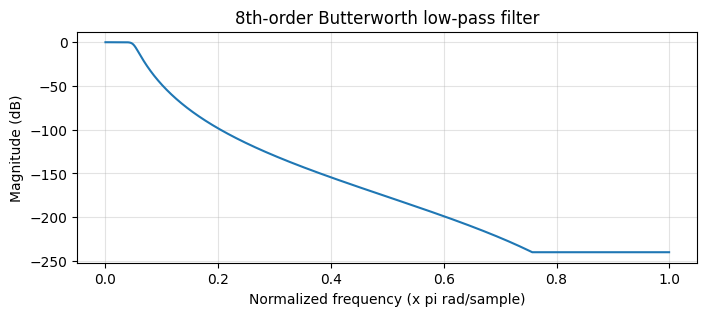

In [2]:
n = np.arange(len(r))
r_mixed = 2 * r * np.exp(-1j * 2 * np.pi * fc * n / fs)

b_lpf, a_lpf = butter(8, 0.05)
r_baseband_filtered = filtfilt(b_lpf, a_lpf, r_mixed.real) + 1j * filtfilt(b_lpf, a_lpf, r_mixed.imag)

w, h = freqz(b_lpf, a_lpf, worN=2048)
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(w / np.pi, 20 * np.log10(np.maximum(np.abs(h), 1e-12)))
ax.set_title("8th-order Butterworth low-pass filter")
ax.set_xlabel("Normalized frequency (x pi rad/sample)")
ax.set_ylabel("Magnitude (dB)")
clean_axes(ax)
plt.show()

## 3.2.2 A/D conversion and Down sampling

Recover the OFDM-rate sequence. The transmitter used an integer interpolation factor, so the correct downsampling factor is 20.

In [3]:
nominal_samples_per_ofdm_sample = fs * Tsym / Nsc
upsampling_factor = int(round(nominal_samples_per_ofdm_sample))

sample_index = np.arange(0, len(r_baseband_filtered), upsampling_factor)
r_ofdm_rate = r_baseband_filtered[sample_index]

print(f"Nominal samples per OFDM sample: {nominal_samples_per_ofdm_sample:.6f}")
print(f"Used integer downsampling factor: {upsampling_factor}")
print(f"Baseband OFDM-rate samples: {len(r_ofdm_rate)}")
print(f"Approximate available OFDM symbols: {len(r_ofdm_rate) // Nofdm}")

Nominal samples per OFDM sample: 19.982813
Used integer downsampling factor: 20
Baseband OFDM-rate samples: 6353
Approximate available OFDM symbols: 42


## 3.2.3 Synchronization and Removal of the Cyclic Prefix

Use the repeated halves in the pilot OFDM symbol for timing, then remove the cyclic prefix before the FFT. Starting slightly early is acceptable because the CP absorbs timing advance; starting late cuts into the useful symbol.

Synchronization metric peak: 4019
Frame start after timing advance: 3989
OFDM symbols extracted: 15


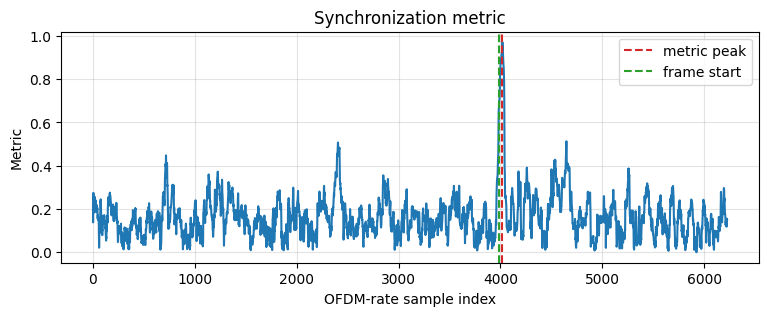

In [4]:
half_symbol = Nsc // 2
windows = sliding_window_view(r_ofdm_rate, 2 * half_symbol)

correlation = np.sum(windows[:, :half_symbol] * np.conj(windows[:, half_symbol:]), axis=1)
energy_1 = np.sum(np.abs(windows[:, :half_symbol]) ** 2, axis=1)
energy_2 = np.sum(np.abs(windows[:, half_symbol:]) ** 2, axis=1)
sync_metric = np.abs(correlation) / np.sqrt(energy_1 * energy_2 + 1e-12)

sync_peak = int(np.argmax(sync_metric))
frame_start = sync_peak - Ncp - (Ncp // 2)
if frame_start < 0:
    raise ValueError("Synchronization selected a negative frame start.")

n_symbols = (len(r_ofdm_rate) - frame_start) // Nofdm
ofdm_blocks = r_ofdm_rate[frame_start:frame_start + n_symbols * Nofdm].reshape(n_symbols, Nofdm)
ofdm_no_cp = ofdm_blocks[:, Ncp:]
X = np.fft.fft(ofdm_no_cp, axis=1)

print(f"Synchronization metric peak: {sync_peak}")
print(f"Frame start after timing advance: {frame_start}")
print(f"OFDM symbols extracted: {n_symbols}")

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(sync_metric)
ax.axvline(sync_peak, color="tab:red", linestyle="--", label="metric peak")
ax.axvline(frame_start, color="tab:green", linestyle="--", label="frame start")
ax.set_title("Synchronization metric")
ax.set_xlabel("OFDM-rate sample index")
ax.set_ylabel("Metric")
ax.legend()
clean_axes(ax)
plt.show()

## 3.2.4 Channel Estimation, Pilot Removal and Calibration

Estimate the channel from the pilot symbol and the known zero padding in the length symbol, then equalize the length and payload symbols.

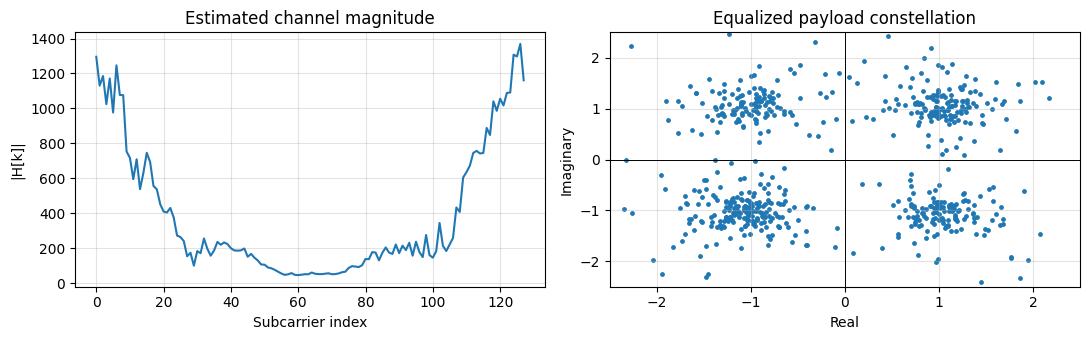

In [5]:
# Pilot OFDM symbol: even Python subcarriers contain 2*P, odd subcarriers are zero.
pilot_subcarriers = np.arange(0, Nsc, 2)
H_pilot = X[0, pilot_subcarriers] / (2 * P)

# Interpolate the missing pilot subcarriers in the complex plane.
all_subcarriers = np.arange(Nsc)
H_from_pilot = (
    np.interp(all_subcarriers, pilot_subcarriers, H_pilot.real)
    + 1j * np.interp(all_subcarriers, pilot_subcarriers, H_pilot.imag)
)

# Length symbol: after 30 encoded length bits, the remaining bits are zero.
# QPSK maps zero-bit pairs 00 to 1+i, so subcarriers 15..127 are known.
length_tail_subcarriers = np.arange(15, Nsc)
H_from_length_tail = X[1, length_tail_subcarriers] / (1 + 1j)

H = H_from_pilot.copy()
H[length_tail_subcarriers] = 0.5 * (H_from_pilot[length_tail_subcarriers] + H_from_length_tail)

X_length_eq = X[1] / H
X_payload_eq_all = X[2:] / H

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(np.abs(H))
axes[0].set_title("Estimated channel magnitude")
axes[0].set_xlabel("Subcarrier index")
axes[0].set_ylabel("|H[k]|")
clean_axes(axes[0])

axes[1].scatter(X_payload_eq_all[:5].real.ravel(), X_payload_eq_all[:5].imag.ravel(), s=6)
axes[1].axhline(0, color="black", linewidth=0.7)
axes[1].axvline(0, color="black", linewidth=0.7)
axes[1].set_title("Equalized payload constellation")
axes[1].set_xlabel("Real")
axes[1].set_ylabel("Imaginary")
axes[1].set_xlim(-2.5, 2.5)
axes[1].set_ylim(-2.5, 2.5)
clean_axes(axes[1])
plt.tight_layout()
plt.show()

## 3.2.5 Decoding and ASCII Conversion

Demap QPSK symbols, Viterbi-decode the convolutional code, read the length bits least-significant-bit first, and convert the decoded payload bits to ASCII.

In [6]:
# Decode the 10-bit message length. The length bits in these signals are LSB-first.
length_coded_bits = qpsk_to_bits(X_length_eq[:15])
decoded_length_bits = viterbi_decode(
    length_coded_bits.astype(float),
    trellis,
    tb_depth=15,
    decoding_type="hard",
).astype(int)
message_length = int(np.dot(decoded_length_bits[:10], 2 ** np.arange(10)))

n_payload_symbols = int(np.ceil((7 * message_length + 5) / Nsc))
if n_payload_symbols > X_payload_eq_all.shape[0]:
    raise ValueError("The decoded message length needs more OFDM symbols than were extracted.")

X_payload_eq = X_payload_eq_all[:n_payload_symbols]
payload_coded_bits = qpsk_to_bits(X_payload_eq)
n_coded_payload_bits = 2 * (7 * message_length + 5)

payload_decoded_bits = viterbi_decode(
    payload_coded_bits[:n_coded_payload_bits].astype(float),
    trellis,
    tb_depth=35,
    decoding_type="hard",
).astype(int)

message_bits = payload_decoded_bits[:7 * message_length]
message = bits_to_ascii(message_bits, message_length)

# The unused QPSK positions after the payload are zero-bit padding, so they map to 1+i.
used_qpsk_symbols = 7 * message_length + 5
last_symbol_used = used_qpsk_symbols - Nsc * (n_payload_symbols - 1)
last_symbol_padding = X_payload_eq[-1, last_symbol_used:]
padding_evm = np.mean(np.abs(last_symbol_padding - (1 + 1j)) ** 2) if len(last_symbol_padding) else 0.0

print(f"Decoded length bits (LSB first): {''.join(decoded_length_bits[:10].astype(str))}")
print(f"Message length: {message_length} characters")
print(f"Payload OFDM symbols used: {n_payload_symbols}")
print(f"Mean EVM in final QPSK padding: {padding_evm:.4f}")
print("Decoded message:")
print(message)

Decoded length bits (LSB first): 0001101000
Message length: 88 characters
Payload OFDM symbols used: 5
Mean EVM in final QPSK padding: 0.1269
Decoded message:
Any linear combination of Gaussian random variables is again a Gaussian random variable.
